# Ex. 9.4
## a)

In [143]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(seed=42)

In [13]:
df = pd.read_csv("../../Datasets_from_the_book/salmon.dat", sep="\s+", dtype=np.float64)
categories = df.columns.tolist()
data = df.to_numpy()

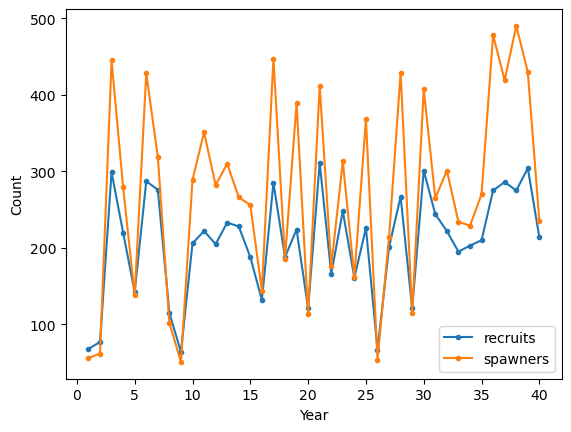

In [25]:
years = data[:,0]
R = data[:,1]
S = data[:,2]

plt.plot(years, R, ".-", label=categories[1])
plt.plot(years, S, ".-", label=categories[2])
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.show()

Given the **Beverton-Holt** model:
$$
R = \frac{1}{\beta_1 + \beta_2/S}
$$

we can use the transformed variables $R = 1/r$ and $S = 1/s$, and rewrite the expression:
$$
\frac{1}{r} = \frac{1}{\beta_1 + \beta_2/\frac{1}{s}}
$$

$$
\frac{1}{r} = \frac{1}{\beta_1 + \beta_2 s}
$$

$$
r = \beta_1 + \beta_2 s
$$

Now we can find the parameters with linear regression, having $r = 1/R$ and $s = 1/S$.

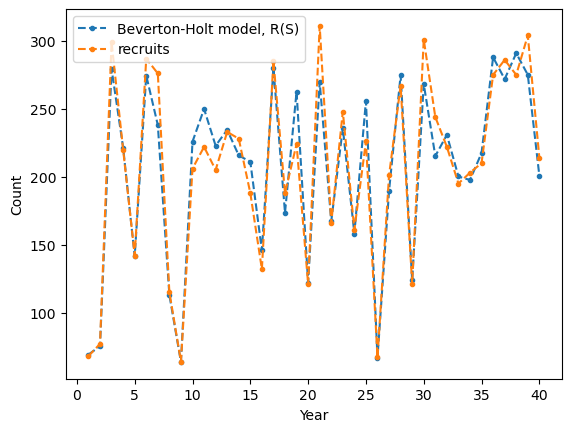

In [69]:
def beverton_holt_model(beta1, beta2, S):
    R = 1.0/(beta1 + (beta2/S))
    return R

r = 1/R
s = 1/S
r = r.reshape(-1,1)
s = s.reshape(-1,1)

model = LinearRegression(fit_intercept=True).fit(X=s, y=r)
beta2 = model.coef_.item()
beta1 = model.intercept_.item()

plt.plot(years, beverton_holt_model(beta1, beta2, S).ravel(), ".--", label="Beverton-Holt model, R(S)")
plt.plot(years, R, ".--", label=categories[1])
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.show()

If $R = S$, we have:
$$
R = \frac{1}{\beta_1 + \beta_2/R}
$$

$$
R(\beta_1 + \beta_2/R) = 1
$$

$$
R\beta_1 + \beta_2 = 1
$$

$$
R = S = \frac{1 - \beta_2}{\beta_1}
$$

In [33]:
RS_opti = ((1- beta2)/beta1)
print(RS_opti)
print(beverton_holt_model(beta1, beta2, RS_opti))

150.0976343009786
150.0976343009786


In [35]:
print(beta1)
print(beta2)

0.0020132306968982543
0.6978188350934615


### Bootstrapping residuals

[0.00185912 0.00217177]
[0.67745275 0.72072009]
8.17e-05
0.0112


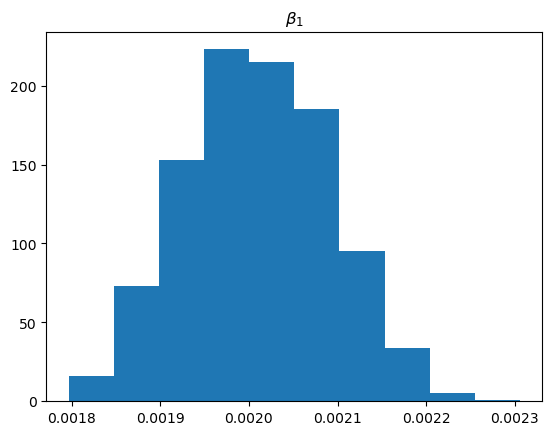

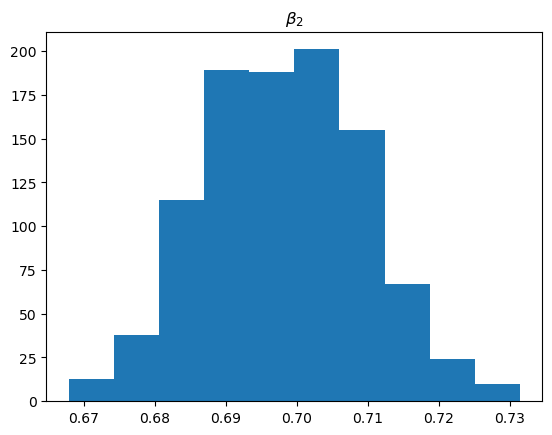

In [328]:
n_bootstraps = 1000
n_samples_per_bootstrap = len(r)
bootstraps_res = np.zeros([n_bootstraps, n_samples_per_bootstrap])

model = LinearRegression(fit_intercept=True).fit(X=s, y=r)
predictions = model.predict(s)
residues = r - predictions

for i in range(n_bootstraps):
    bootstraps_res[i,:] = rng.choice(residues, size=len(residues.ravel()), replace=True).reshape(1,-1)

bootstraps_betas = np.zeros([n_bootstraps, 2])
Y = predictions.reshape(1,-1) + bootstraps_res

for i in range(n_bootstraps):
    new_model = LinearRegression(fit_intercept=True).fit(X=s, y=Y[i,:])
    bootstraps_betas[i,0] = new_model.intercept_.item()
    bootstraps_betas[i,1] = new_model.coef_.item()
    
bootstraped_beta1s = bootstraps_betas[:,0]
bootstraped_beta2s = bootstraps_betas[:,1]

res_confidence_interval95_beta1 = np.percentile(bootstraped_beta1s, [2.5, 97.5])
res_confidence_interval95_beta2 = np.percentile(bootstraped_beta2s, [2.5, 97.5])

print(res_confidence_interval95_beta1)
print(res_confidence_interval95_beta2)

cases_beta1_se = np.std(bootstraped_beta1s)
cases_beta2_se = np.std(bootstraped_beta2s)

print(f"{cases_beta1_se:.3g}")
print(f"{cases_beta2_se:.3g}")

plt.hist(bootstraps_betas[:,0])
plt.title(r"$\beta_1$")
plt.show()

plt.hist(bootstraps_betas[:,1])
plt.title(r"$\beta_2$")
plt.show()

### Bootstrapping cases (pairs)

[0.00185224 0.00216841]
[0.68223765 0.71583997]
8.18e-05
0.00899


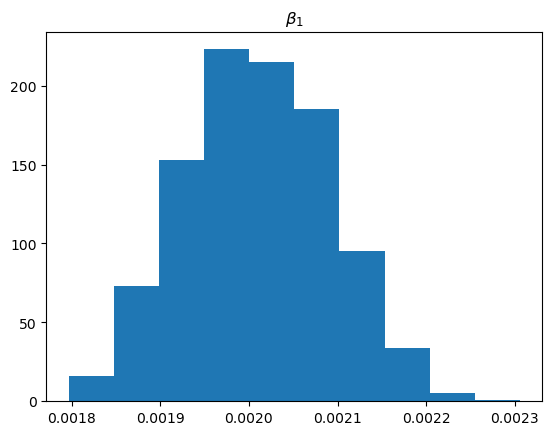

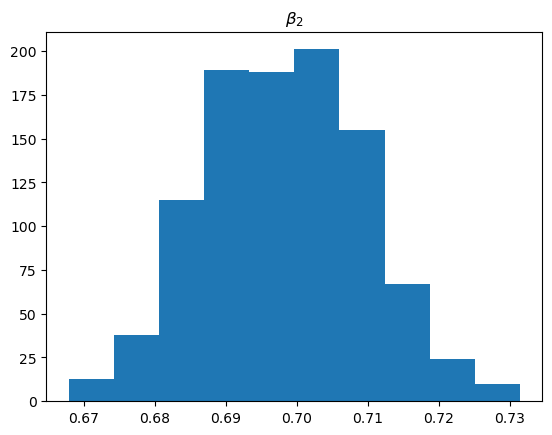

In [ ]:
n_bootstraps = 1000
s_r_pairs = np.concatenate((s, r), axis=1)

# Don't need to store bootstrap array, only array of the betas

stored_betas = np.zeros([n_bootstraps, 2])

for i in range(n_bootstraps):
    bootstrap_pairs = rng.choice(s_r_pairs, size=n_samples_per_bootstrap, replace=True)
    bsample_s = bootstrap_pairs[:,0].reshape(-1,1)
    bsample_r = bootstrap_pairs[:,1].reshape(-1,1)
    model = LinearRegression(fit_intercept=True).fit(X=bsample_s, y=bsample_r)
    stored_betas[i,0] = model.intercept_.item()
    stored_betas[i,1] = model.coef_.item()
    
stored_beta1s = stored_betas[:,0]
stored_beta2s = stored_betas[:,1]

cases_confidence_interval95_beta1 = np.percentile(stored_beta1s, [2.5, 97.5])
cases_confidence_interval95_beta2 = np.percentile(stored_beta2s, [2.5, 97.5])

print(cases_confidence_interval95_beta1)
print(cases_confidence_interval95_beta2)

cases_beta1_se = np.std(stored_beta1s)
cases_beta2_se = np.std(stored_beta2s)

print(f"{cases_beta1_se:.3g}")
print(f"{cases_beta2_se:.3g}")

plt.hist(bootstraps_betas[:,0])
plt.title(r"$\beta_1$")
plt.show()

plt.hist(bootstraps_betas[:,1])
plt.title(r"$\beta_2$")
plt.show()

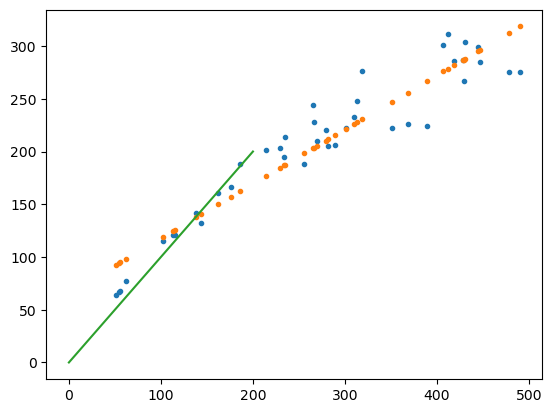

In [255]:
model_R_S = LinearRegression(fit_intercept=True).fit(X=S.reshape(-1,1), y=R.reshape(-1,1))
plt.plot(S,R,".")
plt.plot(S, model_R_S.predict(S.reshape(-1,1)), ".")
plt.plot([0, 200], [0, 200], "-")